# Data Generator Notebook

This notebook generates (non-)Gaussian fields using CAMB and saves them in a .npy file and as tensorboard datasets.

Base code was taken from Thomas

Modifications by Brandon

In [1]:
%load_ext autoreload
%autoreload 2

import os
from copy import deepcopy
from functools import partial
from logging import CRITICAL, DEBUG, ERROR, FATAL, INFO, WARNING

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

from CMBMap import CMBMap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Functions

In [2]:
def _save(dir, filename, maps):
    if not os.path.exists(dir): os.makedirs(dir)
    print(f'Saving {dir}/{filename}...', end=' ')
    with open(f'{dir}/{filename}', 'wb') as f:
        np.save(f, maps)
    print('Done!')

def _make_map(box_size, grid, cosmo, transfers, log_level, fnl, seed=None): #box_size, grid, k_cut_low=None,k_cut_high=None):
    base_field = CMBMap(box_size, grid, cosmo=cosmo, run_camb=False, transfers=transfers, log_level=log_level)
    base_field.GenerateField(f_nl=fnl)
    return base_field.get_map()

def _bispectrum(box_size, grid, cosmo, transfers, log_level, fnl, seed=None):
    base_field = CMBMap(box_size, grid, cosmo=cosmo, run_camb=False, transfers=transfers, log_level=log_level)
    base_field.GenerateField(f_nl=fnl,)
    BBB = base_field.Bk(2.5,3,13, 'All')
    return BBB

def run_simulations(data_dir, name, num_sim, save_steps, box_size, grid, fnls, 
                    force_fnl=None, n_jobs=-1, k_cut_low=None, k_cut_high=None, 
                    log_level=WARNING, cosmo=None, verbose=False):
    print('Generating base field...')
    base = CMBMap(box_size, grid, cosmo=cosmo, log_level=log_level)
    transfers = base.calc_transfers()      
    make_map = partial(_make_map, box_size, grid, cosmo, transfers, log_level) 
    print('Done!')   
    
    for i in range(0, num_sim, save_steps):
        if verbose: print(f'Generating maps {i} to {i + save_steps} out of {num_sim} for {name}...')
        maps_chunk = Parallel(n_jobs=n_jobs, verbose=1)([
            delayed(make_map)( fnl if force_fnl is None else force_fnl ) for fnl in fnls[i:min(i + save_steps, num_sim)]
        ])
        if verbose: print('Done!')
        _save(data_dir, f'{name}_{i}-{i + save_steps}.npy', maps_chunk)

def get_bispectrum(fnl, num_bispectra, box_size, grid, log_level=WARNING, cosmo=None):
    print('Generating base field for bispectrum...')
    base = CMBMap(box_size, grid, cosmo=cosmo, log_level=log_level) 
    transfers = base.calc_transfers()  
    print('Done!') 
        
    bispec = partial(_bispectrum, box_size, grid, cosmo, transfers, log_level) 
    return np.array(Parallel(n_jobs=-1, verbose=1)([delayed(bispec)(fnl) for i in range(num_bispectra)]))

## Test Generation

### Test Settings

In [3]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 2500,
    'accuracy_boost': 4,
    't_cmb': 2.7255,
}

num_bispectra = 10**4
fnl_range=(-1000, 1000)
num_threads = -1 #for all cores
BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 256                          # Size of the grid

# needed values
kF = 2*np.pi / BoxSize              # Fundamental mode of the box
kNyq = kF * grid / 2                # Nyquist frequency of the grid

# Should we only generate the data, skipping tests and fisher forcasts?
run_test = True 

[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 0.7080545106076863


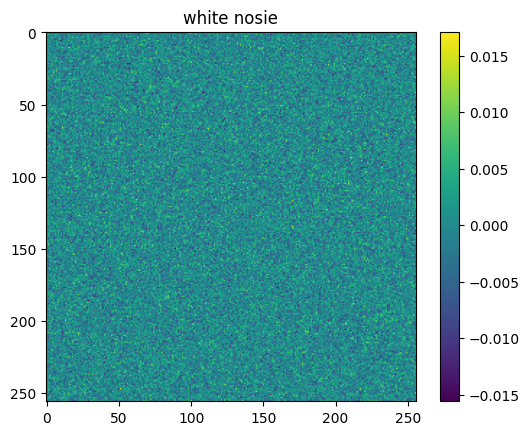

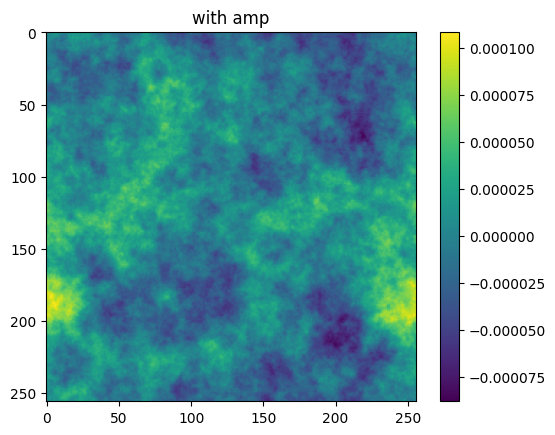

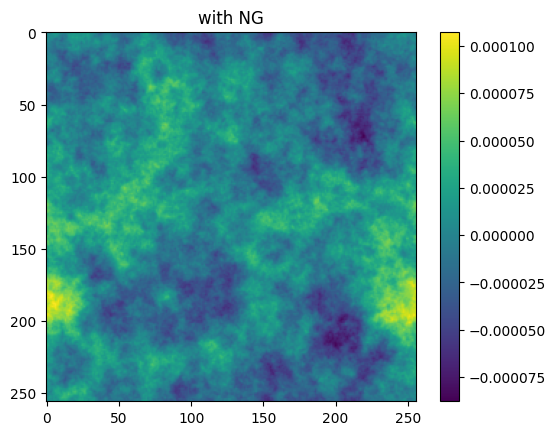

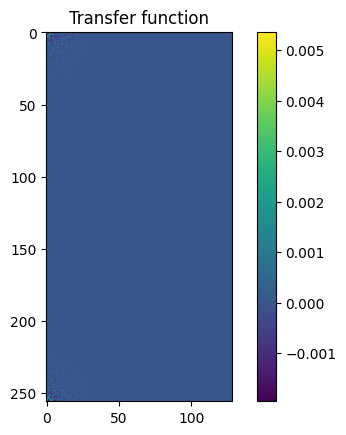

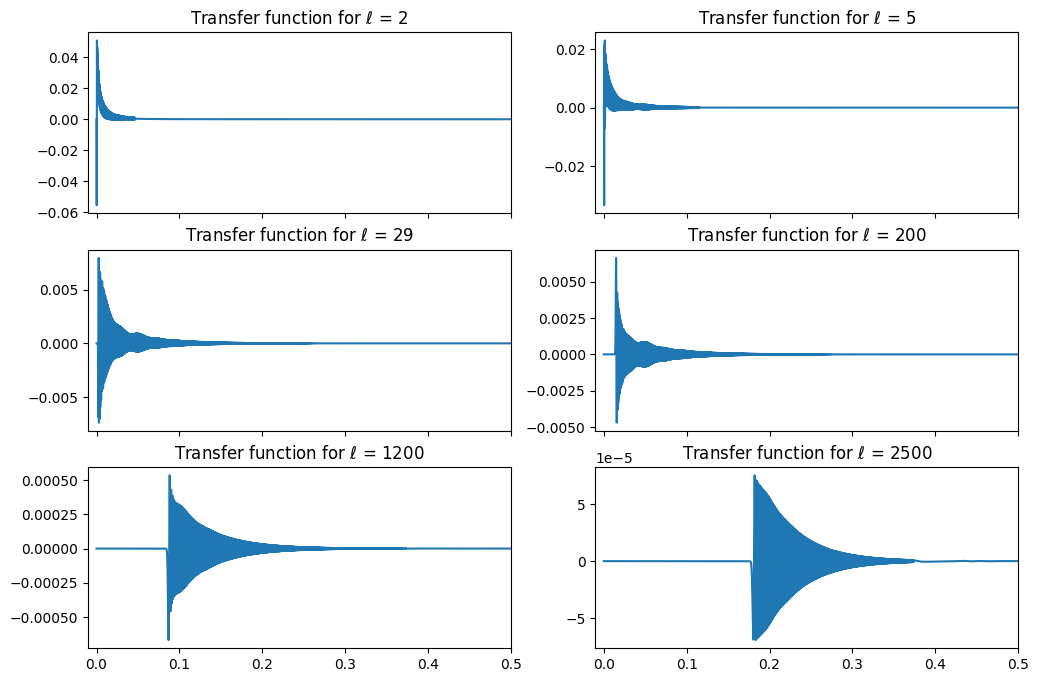

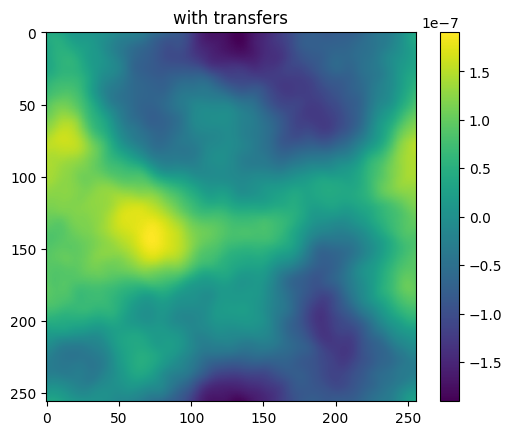

[ CMBMap -        calculate_cls() ] | INFO : PSMap shape: (256, 129), min: 0.0, max: 5.644257412739764e-06, mean: 5.766420644867067e-10, rms: 5.004153706979585e-08


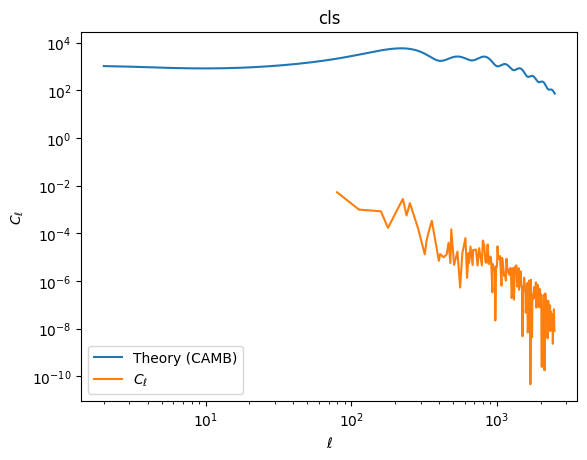

[ CMBMap -             plot_cmb() ] | INFO : map mean: -8.271806125530277e-25 map rms: 7.868026987355251e-08


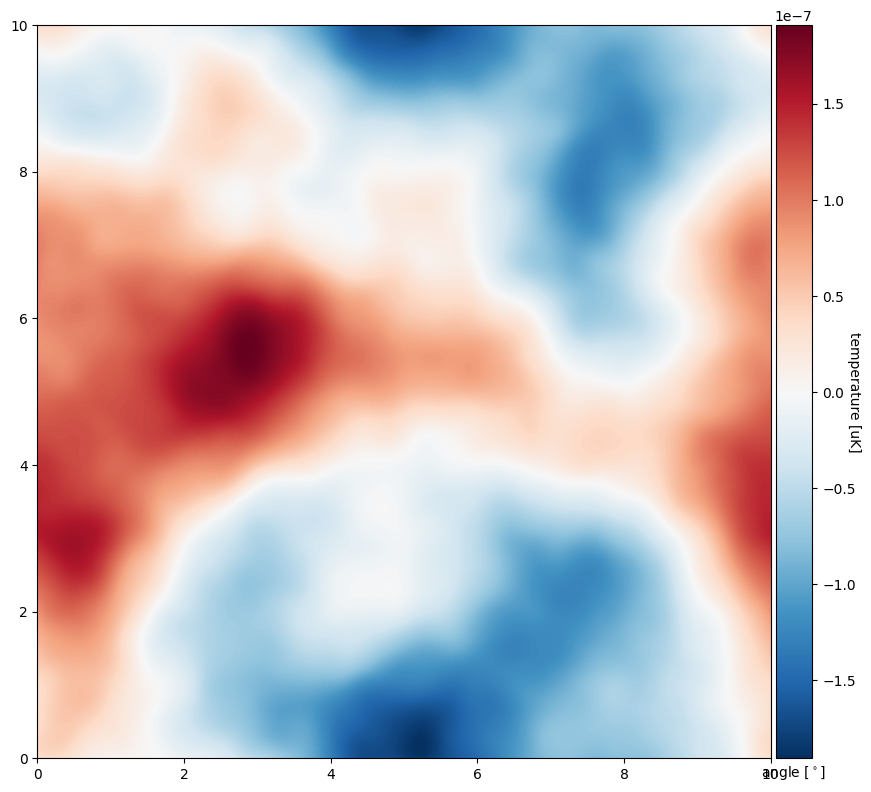

In [4]:
if run_test:
    test_map = CMBMap(BoxSize, grid, cosmo=cosmo_params, log_level=INFO)
    test_map.GenerateField(f_nl=1.,seed=0, plot=True)
    
    test_map.plot_cls(title='cls')
    test_map.plot_cmb()

Now we test camb with a non-linear power spectrum

[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 0.7080545106076863
[ CMBMap -             plot_cmb() ] | INFO : map mean: -8.271806125530277e-25 map rms: 7.868026987355251e-08


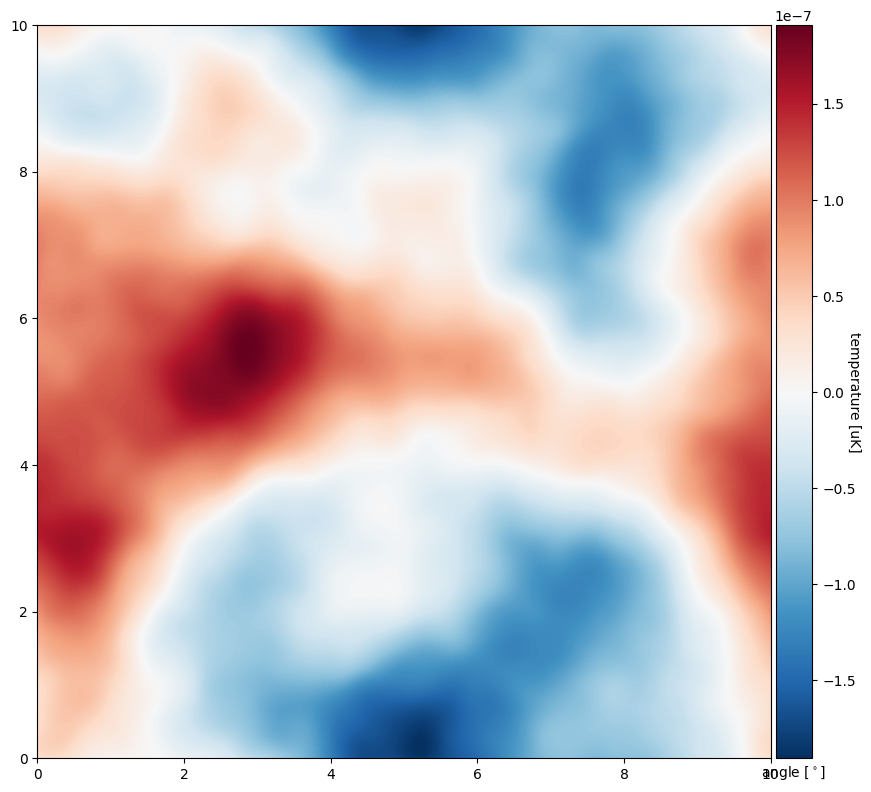

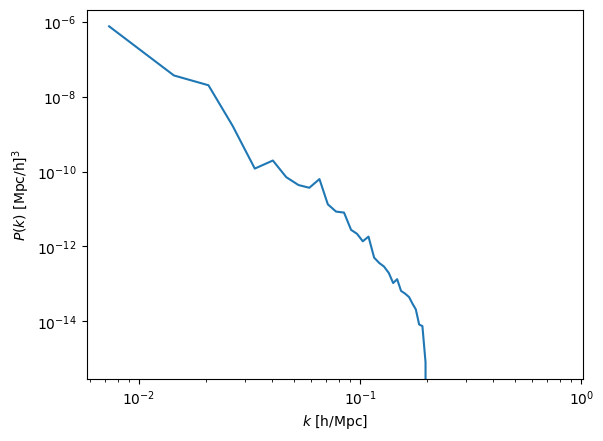

In [5]:
if run_test:
    FFT_map = CMBMap(BoxSize,grid,cosmo=cosmo_params)
    
    # Generate the same field but cut off at grid/3*kF (where FFT bispectrum measurements start to fail)
    FFT_map.GenerateField(f_nl=1.,k_cut_high=grid/3*kF)
    
    FFT_map.plot_cmb()
    
    kk, Pk, _ = FFT_map.Pk()
    plt.loglog(kk,Pk)
    plt.ylabel("$P(k)$ [Mpc/h]$^3$")
    plt.xlabel("$k$ [h/Mpc]")
    plt.show()

## Fisher Forecast

Computing Bispectra can be done as follows

kmax = 0.25132741228718347 0.536165146212658


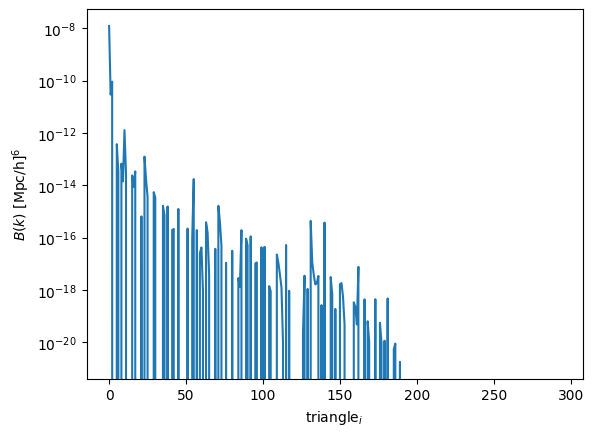

In [6]:
if run_test:
    # Compute the bispectrum in a given binning:
    BBB = FFT_map.Bk(2.5,3,13,'All')

    plt.semilogy(BBB[:,-2])
    plt.ylabel("$B(k)$ [Mpc/h]$^6$")
    plt.xlabel("triangle$_i$")
    print("kmax =",(BBB[-1,0]+1.5)*kF,grid/3*kF)

### Perform a Fisher forecast

We compute many bispectra with fixed amounts of pnG

In [7]:
if run_test:
    BispecP = get_bispectrum(100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecM = get_bispectrum(-100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecG = get_bispectrum(0, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)

Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 0.7080545106076863
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 484 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 1184 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 2084 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 4484 tasks      | elapsed:   24.5s
[Parallel(n_jobs=-1)]: Done 5984 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 7684 tasks      | elapsed:   31.4s
[Parallel(n_jobs=-1)]: Done 9584 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done 9937 out of 10000 | elapsed:   36.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   36.4s finished


Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 0.7080545106076863
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1224 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 2624 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 4424 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 6624 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done 9224 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 9937 out of 10000 | elapsed:   21.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   21.4s finished


Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 0.7080545106076863
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1224 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 2624 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 4424 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 6624 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 9224 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 9937 out of 10000 | elapsed:   20.7s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   20.8s finished


We compute the covariance matrix and its inverse, corrected by the Hartlap factor

In [8]:
if run_test:
    Cov = np.cov(BispecG[:,:,-2].T)

    hartlapfactor = (len(BispecG) - len(Cov) - 2) / (len(BispecG) - 1)
    print(Cov)
    Cov_Inv = np.linalg.inv(Cov)
    Cov_Inv *= hartlapfactor

    Cov = np.diag(np.diag(Cov))
    plt.semilogy(np.diag(Cov))
    print(hartlapfactor)

[[ 1.10585002e-43 -1.24433917e-45 -3.28385190e-45 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.24433917e-45  1.40017176e-47  3.69509922e-47 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.28385190e-45  3.69509922e-47  9.75148809e-47 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


LinAlgError: Singular matrix

We compute the derivative of the bispectra with respect to $f_{\rm NL}$

In [ ]:
if run_test:
    dBdf = (BispecP.mean(0)[:,-2]-BispecM.mean(0)[:,-2])/200
    plt.semilogy(dBdf)
    plt.show()

### Then the Fisher information is given by $$F = \sum_{TT'} \frac{\partial B_T}{f_{\rm NL}} C^{-1}_{TT'} \frac{\partial B_{T'}}{f_{\rm NL}}$$ and the measurement error is $\sigma_{f_{\rm NL}} = F^{-1/2}$

In [ ]:
if run_test:
    FF = (dBdf.dot(Cov_Inv).dot(dBdf))
    sigma = FF**-.5
    print(sigma)

### One can also estimate $f_{\rm NL}$ from the generated bispectra: $$\hat{f}_{\rm NL} = F^{-1}\sum{TT'}\frac{\partial B_T}{f_{\rm NL}}C^{-1}_{TT'} B_{T'}$$ where $B_{T'}$ is a measured bispectrum

In [ ]:
if run_test:
    estimates_P = np.array([dBdf.dot(Cov_Inv).dot(BispecP[i,:,-2])/FF for i in tqdm(range(len(BispecP)))])
    estimates_M = np.array([dBdf.dot(Cov_Inv).dot(BispecM[i,:,-2])/FF for i in tqdm(range(len(BispecM)))])
    estimates_G = np.array([dBdf.dot(Cov_Inv).dot(BispecG[i,:,-2])/FF for i in tqdm(range(len(BispecG)))])

In [ ]:
if run_test: 
    print(estimates_P.mean(), estimates_M.mean(), estimates_G.mean())

In [ ]:
if run_test:
    print(estimates_P.std(), estimates_M.std(), estimates_G.std())

In [ ]:
if run_test:
    plt.hist(estimates_P,bins=100)
    plt.hist(estimates_G,bins=100)
    plt.hist(estimates_M,bins=100)
    plt.legend()
    plt.show()

In [ ]:
if run_test:
    plt.plot(BispecP.mean(0)[:,-2]*BispecP[0,:,:3].prod(1)*kF**3)
    plt.plot(BispecM.mean(0)[:,-2]*BispecM[0,:,:3].prod(1)*kF**3)
    plt.plot(BispecG.mean(0)[:,-2]*BispecG[0,:,:3].prod(1)*kF**3)

# Map Generation

Now we generate and save the corresponding maps.

## Generator Settings

In [11]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 2500,
    'accuracy_boost': 4,
    't_cmb': 2.7255,
}

## simulations settings
num_sim = 10**4 # number of files to generate
num_steps = 10**4 # Number of steps to use per file (keeps memory usage low)
fnl_range=(-1000, 1000)

BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 128                          # Size of the grid

# Number of threads to use
num_threads = -1 # for all cores

## Data Settings
base_name = f'{grid}x{num_sim//1000}k_fnl{fnl_range[0]}-{fnl_range[1]}'
data_file = f"{base_name}"
fnl_file = f"{base_name}-fnls"

data_dir=f'data/camb/{base_name}'
if not os.path.exists(data_dir): os.makedirs(data_dir)

# Generate extra maps such as fixed fnl maps
create_aux = True

In [12]:
print(f'Generating Field with {num_sim} runs of resolution {grid}, box size {BoxSize} Mpc/h')
print(f'base_name: {base_name}\ndir: {data_dir}\ndata file: {data_file}\nfnl file: {fnl_file}')

Generating Field with 10000 runs of resolution 128, box size 1000.0 Mpc/h
base_name: 128x10k_fnl-1000-1000
dir: data/camb/128x10k_fnl-1000-1000
data file: 128x10k_fnl-1000-1000
fnl file: 128x10k_fnl-1000-1000-fnls


## Generate / Load FNLs

Start by generating the fnls, loading them if possible 

In [13]:
%%time

fnl_path = os.path.join(data_dir, fnl_file + '.npy')
if os.path.exists(fnl_path):
    print(f'Loading existing fnls from {fnl_path}...')
    fnls = np.load(fnl_path)
    np.random.shuffle(fnls) # just add randomness between runs
else:
    print(f'Generating new fnls and saving to {fnl_path}...')
    fnls = np.random.uniform(fnl_range[0], fnl_range[1], num_sim).astype(np.float32)
    _save(data_dir, fnl_file + '.npy', fnls)

Loading existing fnls from data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000-fnls.npy...
CPU times: user 393 µs, sys: 4.01 ms, total: 4.4 ms
Wall time: 39.9 ms


Now we can run our simulations

In [14]:
%%time
run_simulations(data_dir, base_name, num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads) #, k_cut_high=0.25132741228718347)

Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 244 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4256 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 9546 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    2.8s finished


Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_0-10000.npy... Done!
CPU times: user 13min 55s, sys: 19.7 s, total: 14min 14s
Wall time: 36.4 s


## Generate AUX maps

In [15]:
if create_aux:
    print('Creating auxillary files use for additional analysis...')
    run_simulations(data_dir, f"{base_name}_fnl-100", num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=-100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl0"   , num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=0, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl100" , num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_highcut", num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads, k_cut_high=1.1*kF)
    run_simulations(data_dir, f"{base_name}_lowcut" , num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads, k_cut_low=1.1*kF)

Creating auxillary files use for additional analysis...
Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4448 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 9558 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    2.8s finished


Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_fnl-100_0-10000.npy... Done!
Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 232 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4160 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 9540 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    2.9s finished


Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_fnl0_0-10000.npy... Done!
Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


...

Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_fnl100_0-10000.npy... Done!
Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4096 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 9536 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    2.6s finished


Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_highcut_0-10000.npy... Done!
Generating base field...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 't_cmb': 2.7255}
[ CMBMap -             run_camb() ] | INFO : d_A: 18965.627818476176, pix size: 1.4161090212153726
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4096 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 9536 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    3.0s finished


Saving data/camb/128x10k_fnl-1000-1000/128x10k_fnl-1000-1000_lowcut_0-10000.npy... Done!
